# Time series extraction
---

Running this notebook you will:

- Extract the timeseries for each video 
- Verify that the threshold used for the boarder segmentation is good

## Mount google drive

Please mount your google drive and find your working folder with the data you uploaded. 

In [1]:
#@markdown ###Step 1. Run this cell to connect your Google Drive to Colab and install packages

#@markdown * Click on the URL. 

#@markdown * Sign in your Google Account. 

#@markdown * Click on "Files" site on the right. Refresh the site. Your Google Drive folder should now be available here as "drive". 

#mounts user's Google Drive to Google Colab.

from google.colab import drive
drive.mount('/content/gdrive')

%cd /content/gdrive/MyDrive/NMO-colab/ 

!pip install readlif

Mounted at /content/gdrive
/content/gdrive/MyDrive/NMO-colab
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [2]:
#@markdown ###Step 2. Import
#@markdown Execute this cell to import the necessary packages
import os
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
%matplotlib inline
from matplotlib import pyplot as plt
from math import sqrt, ceil, hypot, degrees, atan

from scipy.ndimage.morphology import binary_fill_holes
from scipy import interpolate
from skimage import feature
from skimage.filters import threshold_otsu, gaussian
from skimage.transform import rotate, SimilarityTransform
from skimage.morphology import disk, erosion, remove_small_holes, binary_opening, remove_small_objects
from skimage.io import imsave

from readlif.reader import LifFile
import ipywidgets as ipyw

In [5]:
#@markdown ###Step 3. Data path
#@markdown ####Write the path to your data (lif video files):

src_filepath = 'videos' #@param {type:"string"}

#@markdown ####And the path of the folder where to save the extracted signals:

dst_filepath = 'extracted_signals' #@param {type:"string"}

def remove_border_points(border_points):
    '''Remove the white pixels on border of image'''
    border_x = list(border_points[0])
    border_y = list(border_points[1])
    i = 0
    remove_ids = []
    for x, y in zip(border_x, border_y):
        if x<2 or x>252 or y<5 or y>252: remove_ids.append(i)
        i+=1
    for i in reversed(remove_ids):
        border_x.pop(i)
        border_y.pop(i)
    return (np.array(border_x), np.array(border_y))

def get_thresh(img_slice0, sigma_smooth=2):
  img_smooth = gaussian(img_slice0, sigma_smooth)
  thresh = threshold_otsu(img_smooth)
  return thresh, np.min(img_smooth), np.max(img_smooth)

def extract_border(img_slice, thresh, sigma_smooth=2, sigma_edge=3):
    '''
    Extract the border from a single frame, by following:
    1. Threshold image using Otsu thresholding
    2. Apply morphological opening and fill any holes in the binary image
    3. Compute edges using the Canny edge Detection algorithm
    4. Remove white pixels from border of image
    6. Return border coordinates and binary image
    '''
    img_smooth = gaussian(img_slice, sigma_smooth)
    image_thresh = img_smooth > thresh
    image_thresh = binary_opening(image_thresh, disk(4))
    image_thresh = remove_small_objects(image_thresh, min_size=400)
    
    edges = feature.canny(image_thresh, sigma_edge)
    x,y = remove_border_points((np.where(edges)))

    return (x,y), image_thresh

def sort_border(x,y):
    ''' Sort border pixels such that the signal coordinates are continuous'''
    sorted_x = x[np.argsort(x)] # sort x values
    sorted_y = y[np.argsort(y)] # sort y values 
    max_dist_x = sorted_x[-1] - sorted_x[0] # compute max distance on x axis
    max_dist_y = sorted_y[-1] - sorted_y[0] # compute max distance on y axis
    # if x changes more than y
    if max_dist_x > max_dist_y: point0 = np.where(x==sorted_x[0])[0][0] # sort (x,y) points according to x
    # else sort (x,y) points according to y
    else: point0 = np.where(y==sorted_y[0])[0][0]

    sorted_ids = np.argsort((x-x[point0])**2+(y-y[point0])**2) # x+y
    x = x[sorted_ids]
    y = y[sorted_ids]
    return (x,y)

def get_border_angle(x , y):
    ''' Compute the angle of the border considering it as a line from first to last point'''
    xl = x[-1] - x[0]
    yl = y[-1] - y[0]
    theta = degrees(atan(xl/yl))
    # if theta is negative and the border is sorted according to x we want to rotate counter-clockwise 
    # and by 180+theta to make sure x[0], y[0] moves to the begining of the signal
    if y[0] > y[-1]: theta = 180+theta 
    return theta

#@markdown Now execute this cell

In [6]:
#@markdown ###Step 4. File selection 
files = [file for file in os.listdir(src_filepath) if file.endswith('.lif')]
print('Dataset includes ', len(files), ' videos')

#@markdown Execute the cell and **then** select the video you wish work on.

wig = ipyw.Dropdown(
    options=files,
    description='Video:'
)
display(wig)


Dataset includes  8  videos


Dropdown(description='Video:', options=('O1449_1a.lif', 'O1448_2a.lif', 'O1449_1b.lif', 'O4979_1a.lif', 'O4979…

In [7]:
#@markdown ###Step 5.Treshold selection for obtaining organoid border 
file_id = files.index(wig.value)
print("Opening file: ", files[file_id])
# read image
img = LifFile(os.path.join(src_filepath, files[file_id]))
img = img.get_image(0)
img_array = [i for i in img.get_iter_t(c=0, z=0)]
img_array = np.stack(img_array)

thresh, min_int, max_int = get_thresh(img_array[0])
img_gaussian = gaussian(img_array, 2)
thresh = round(thresh,2)
print('Default threshold value is: ', thresh)

Opening file:  O4980_2c-curare.lif
Default threshold value is:  0.62


In [8]:
#@markdown ###Step 6. Verifying threshold
#@markdown Execute this cell to have a look at the border we get with the automatic threshold. 
#@markdown You can scroll through the video frames and change the default threshold to choose a 
#@markdown value which will result in a good organoid/background seperation. The higher the threhsold the more lighter regions it will include.
class ImageSliceViewer3D:
    """ 
    ImageSliceViewer3D is for viewing volumetric image slices in jupyter or
    ipython notebooks. 
    
    User can interactively change the slice plane selection for the image and 
    the slice plane being viewed. 

    Argumentss:
    Volume = 3D input image
    figsize = default(8,8), to set the size of the figure
    cmap = default('plasma'), string for the matplotlib colormap. You can find 
    more matplotlib colormaps on the following link:
    https://matplotlib.org/users/colormaps.html
    
    """
    
    def __init__(self, volume_g, volume, threshold, figsize=(15,15), cmap='gray'):
        self.volume_g = volume_g
        self.volume = volume
        self.threshold = threshold
        self.figsize = figsize
        self.cmap = cmap
        self.v = [np.min(volume), np.max(volume)]
        
        # Call to view a slice within the selected slice plane
        ipyw.interact(self.change_thresh, 
            t=ipyw.FloatSlider(value=self.threshold, min=0, max=1, step=0.01, continuous_update=False, 
            description='Threshold:', readout_format='.2f'))
        
    def change_thresh(self, t): 
      mask = self.volume_g > t
      self.img_copy = self.volume.copy()
      bar = ipyw.IntProgress(value=0, min=0, max=len(range(mask.shape[0])), description='Loading:',
                       bar_style='', # 'success', 'info', 'warning', 'danger' or ''
                       #style={'bar_color': 'maroon'},
                       #orientation='horizontal'
                       )
      display(bar)
      for i in range(mask.shape[0]):
        bar.value = i
        mask[i] = binary_opening(mask[i], disk(4))
        mask[i] = remove_small_objects(mask[i], min_size=400)  
        mask[i] = feature.canny(mask[i], 3)
        img_temp = self.volume[i].copy()
        img_temp[mask[i]==1] = 255
        self.img_copy[i] = img_temp

      bar.bar_style = 'success'
      maxZ = self.volume.shape[0] - 1
      ipyw.interact(self.plot_slice, 
          z=ipyw.IntSlider(min=0, max=maxZ, step=1, continuous_update=False, 
          description='Time Frames:', layout=ipyw.Layout(width='100%')))


    def plot_slice(self, z):
        # Plot slice for the given plane and slice
        self.fig = plt.figure(figsize=self.figsize)
        plt.imshow(self.img_copy[z], cmap=plt.get_cmap(self.cmap), 
            vmin=self.v[0], vmax=self.v[1])
        
           
ImageSliceViewer3D(img_gaussian, img_array, thresh)


interactive(children=(FloatSlider(value=0.62, continuous_update=False, description='Threshold:', max=1.0, step…

In [9]:
#@markdown ###Step 7. Setting of final threhsold
#@markdown ####Set the threshold you chose in the previous step and **then** execute this cell.

thresh = 0.69 #@param {type:"number"}

# Open data info file
data_info = pd.read_excel('Contraction_videos_legend.xlsx')
data_info.rename(columns={'File_video name': 'Filename'}, inplace=True)
data_info['Filename'] = data_info['Filename'].apply(lambda x: os.path.splitext(os.path.basename(x))[0])

# Add chosen threshold value to the info file
# data_info.insert(10,'Threshold', 'default') # only first time
data_info.loc[data_info['Filename'] == os.path.splitext(os.path.basename(wig.value))[0], 'Threshold'] = thresh
data_info.to_excel("Contraction_videos_legend.xlsx", index=False)
# data_info

In [10]:
#@markdown ###Step 8. Signal extraction

def extract_signal(img_array, thresh):

  border_size = []
  med_y = []
  rotated_masks = []
  num_frames = img_array.shape[0]
  print('Going to use threshold: ', thresh)

  # and go a second time over to extract signals 
  for frame_id in range(num_frames):

    # extract border and sort pixels
    (x,y), _ = extract_border(img_array[frame_id], thresh)
    x, y = sort_border(x, y)
    # Rotate border so that is always parallel to x-axis
    theta = get_border_angle(x , y)
    mask = np.zeros(img_array[frame_id].shape, dtype=bool)
    mask[(x,y)] = True #size 256, 256
    mask_r = rotate(mask, theta, resize=True) # shape usually 305,305 but changes
    
    # store rotated image and length of border
    y = np.sort(np.where(mask_r)[1])
    dist_y = y[-1] - y[0]
    med_y.append(dist_y//2 + y[0])
    border_size.append(dist_y)
    rotated_masks.append(mask_r)

  # get minimum border length and where the border is minimized
  border_size = np.array(border_size)
  bbox_size = np.min(border_size)
  median_y = med_y[np.argmin(border_size)]

  if bbox_size%2==1: bbox_size-=1
  if bbox_size<100:
    print('The organoid is moving strongly in this video and the border is not enitrely visible in the scene in all frames.\n',
    'For this reason we will only export signals for 5 sub-regions of the border')
    subsample_regions = 5
  else:
    subsample_regions = 10
  distances = np.zeros((subsample_regions, num_frames))
  x_crop = 250

  del border_size
  del img_array
  del x
  del y
  del mask

  for frame_id in range(num_frames):

    mask_r = rotated_masks[frame_id]

    # Pad so we always have a fixed size image
    resize_size = (1024 - mask_r.shape[0], 512 - mask_r.shape[1])
    mask_r = np.pad(mask_r, ((resize_size[0]//2+mask_r.shape[0]%2, resize_size[0]//2), (resize_size[1]//2+mask_r.shape[1]%2, resize_size[1]//2)))
    
    # readjust median y to new img size
    median_yf = median_y + resize_size[1]//2+mask_r.shape[1]%2
    
    # Translate always relative to middle of image and around median of columns
    if frame_id==0: 
      where_border = np.where(mask_r)
      mean_x = round(np.mean(where_border[0]))

    # crop edges of border so hopefully we are always including the same border points
    mask_r = mask_r[mean_x-x_crop:mean_x+x_crop, median_yf-bbox_size//2:median_yf+bbox_size//2]\
    
    # get new img size and size of subsampled regions
    new_height, new_width = mask_r.shape
    subsample_area = new_width//subsample_regions

    # get the average of coordinates in sub-region along the x-axis and subtract from average if frame0
    for i in range(subsample_regions):
      sub_area = mask_r[:,i*subsample_area:(i+1)*subsample_area]
      x_sub, _ = np.where(sub_area)
      distances[i, frame_id] = np.mean(x_sub)

  return distances, subsample_regions

distances, subsample_regions = extract_signal(img_array, thresh)

# save result in numpy file
for i in range(subsample_regions):
  distances[i, :] -= distances[i,0]
new_file = os.path.join(dst_filepath, Path(files[file_id]).stem+'.npy')
np.save(new_file, distances) #add dst_path

print(subsample_regions, ' signals were extracted from this video file and saved in: ', new_file) 

d = np.load(new_file)
if np.any(np.isnan(d)):
 print('There may be a problem with this file, as it includes NaN values which can cause problems in the downstream analysis. Please check again that your threshold makes sense. If the problem persists please contact the Helmholtz AI consultants.')


Going to use threshold:  0.69


<ipython-input-5-c20ce79c360a>:68: RuntimeWarning: divide by zero encountered in long_scalars
  theta = degrees(atan(xl/yl))


10  signals were extracted from this video file and saved in:  extracted_signals/O4980_2c-curare.npy


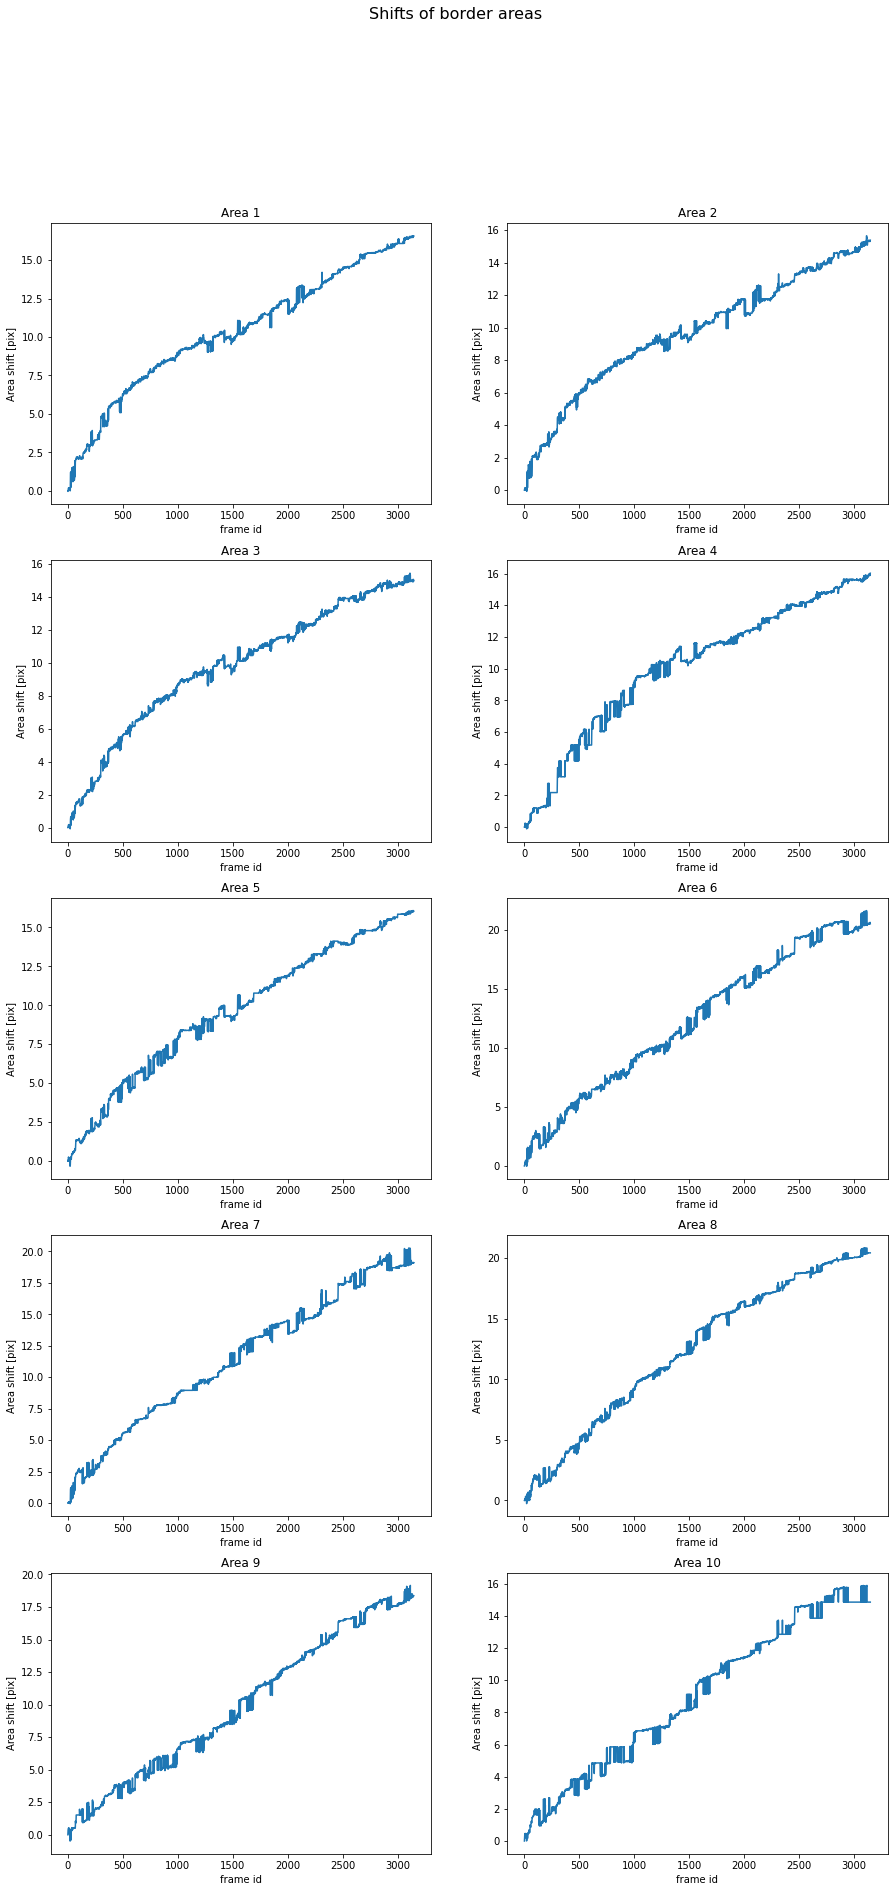

In [11]:
#@markdown ###Step 9. Visualise results

#@markdown Run this cell to see the signals that were extracted. You can then return to Step 4 if you wish to work on a new organoid contraction video :)
if subsample_regions==10: 
  cols=2
  fig, ax = plt.subplots(5, cols, figsize=(15,30))
  fig.suptitle('Shifts of border areas', fontsize=16)
  for i in range(subsample_regions):
    ax[i//2, i%2].plot(np.arange(distances.shape[1]), distances[i,:])
    ax[i//2, i%2].set_title('Area '+str(i+1), fontsize=12)
    ax[i//2, i%2].set_xlabel('frame id', fontsize=10)
    ax[i//2, i%2].set_ylabel('Area shift [pix]', fontsize=10)
else:
  fig, ax = plt.subplots(5, figsize=(15,30))
  fig.suptitle('Shifts of border areas', fontsize=16)
  for i in range(subsample_regions):
    ax[i].plot(np.arange(distances.shape[1]), distances[i,:])
    ax[i].set_title('Area '+str(i+1), fontsize=12)
    ax[i].set_xlabel('frame id', fontsize=10)
    ax[i].set_ylabel('Area shift [pix]', fontsize=10)